In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import seaborn as sns

In [7]:
df_clean_details = pd.read_csv('data/clean_king_county_house_details.csv', sep=";")
df_clean_details.head(20)
df_clean_sales = pd.read_csv('data/clean_king_county_house_sales.csv', sep=";")
df_clean_sales.head(20)

,date,price,house_id,id
0,2014-10-13,221900.0,7129300520,1
1,2014-12-09,538000.0,6414100192,2
2,2015-02-25,180000.0,5631500400,3
3,2014-12-09,604000.0,2487200875,4
4,2015-02-18,510000.0,1954400510,5
5,2014-05-12,1230000.0,7237550310,6
6,2014-06-27,257500.0,1321400060,7
7,2015-01-15,291850.0,2008000270,8
8,2015-04-15,229500.0,2414600126,9
9,2015-03-12,323000.0,3793500160,10


In [8]:
# merge tables
df = pd.merge(
    df_clean_details,
    df_clean_sales,
    left_on="id",
    right_on="house_id",
    how="inner"
)

# treat waterfront == 5 as NaN
df["waterfront"] = df["waterfront"].replace(5, np.nan)

# remove NaN waterfront rows
df = df.dropna(subset=["waterfront"])

# renovation indicator
df["renovated"] = df["yr_renovated"] > 0

In [9]:
fraction_table = (
    df.groupby("waterfront")["renovated"]
    .value_counts(normalize=True)
    .unstack()
)

print(fraction_table)

renovated      False     True 
waterfront                    
0.0         0.789507  0.210493
1.0         0.630137  0.369863


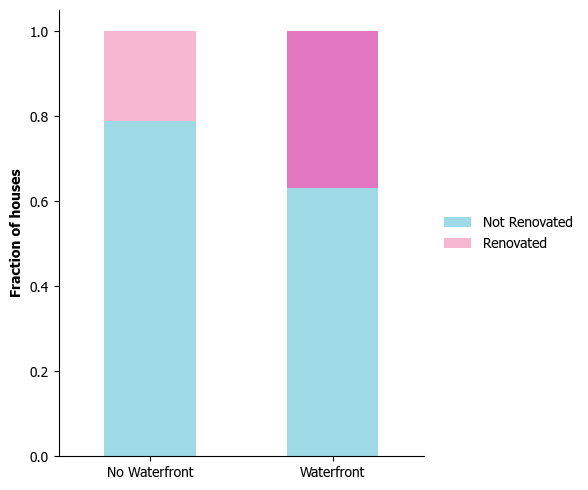

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# font
mpl.rcParams["font.family"] = "Tahoma"

fig, ax = plt.subplots(figsize=(6,5))

fraction_table.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#9EDAE5", "#E377C2"]
)

# group labels
ax.set_xticks([0,1])
ax.set_xticklabels(["No Waterfront", "Waterfront"], rotation=0)

# axis labels
ax.set_ylabel("Fraction of houses", fontweight="bold")
ax.set_xlabel("")   # remove x-axis title

# remove top/right frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# change renovated/no-waterfront to light pink
patches = ax.patches
patches[2].set_facecolor("#F7B6D2")
patches[3].set_facecolor("#E377C2")

# legend
ax.legend(
    ["Not Renovated","Renovated"],
    frameon=False,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

# transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()
plt.show()

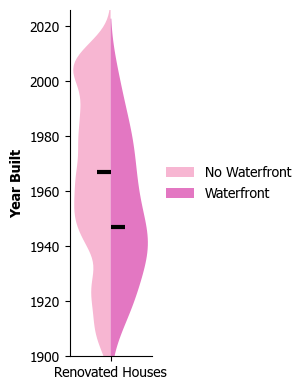

In [11]:



# -----------------------------
# load data (ensure dataframe exists)
# -----------------------------
df_clean_details = pd.read_csv(
    "data/clean_king_county_house_details.csv",
    sep=";"
)

mpl.rcParams["font.family"] = "Tahoma"

# -----------------------------
# prepare dataframe
# -----------------------------
df = df_clean_details.copy()

# clean waterfront column
df["waterfront"] = df["waterfront"].replace(5, np.nan)

# renovated flag
df["renovated"] = df["yr_renovated"] > 0

# keep renovated houses only
df_ren = df[(df["renovated"]) & (df["waterfront"].isin([0,1]))].copy()

# readable group labels
df_ren["WaterfrontGroup"] = df_ren["waterfront"].map({
    0: "No Waterfront",
    1: "Waterfront"
})

df_ren["Group"] = "Renovated Houses"

# -----------------------------
# plot
# -----------------------------
fig, ax = plt.subplots(figsize=(3.2,4))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

sns.violinplot(
    data=df_ren,
    x="Group",
    y="yr_built",
    hue="WaterfrontGroup",
    split=True,
    inner=None,
    palette=["#F7B6D2", "#E377C2"],
    linewidth=0,
    saturation=1,
    ax=ax
)

# remove edges
for violin in ax.collections:
    violin.set_alpha(1)
    violin.set_edgecolor("none")

# median lines
medians = df_ren.groupby("WaterfrontGroup")["yr_built"].median()

ax.hlines(medians["No Waterfront"], -0.15, 0, colors="black", linewidth=3)
ax.hlines(medians["Waterfront"], 0, 0.15, colors="black", linewidth=3)

# axes formatting
ax.set_ylim(1900, 2026)
ax.set_xlabel("")
ax.set_ylabel("Year Built", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, bbox_to_anchor=(1.02,0.5), loc="center left", title="")

plt.tight_layout()
plt.show()